# 🧠 Xception Transfer Learning - Image Classification
This notebook demonstrates how to use Xception with transfer learning on a small custom dataset.

***IMPORT LIBRARIES***

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import GlobalAveragePooling2D,Dense,Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import os

***DATASET LINK***
https://drive.google.com/file/d/1TCU1nqgIe1R_dW6LTkRxlufHlCCazyJl/view?usp=sharing

In [2]:
import gdown

# Google Drive file ID
file_id = "1TCU1nqgIe1R_dW6LTkRxlufHlCCazyJl"

# download destination file
output = 'myfile.zip'

# download file
gdown.download(f"https://drive.google.com/uc?id={file_id}", output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1TCU1nqgIe1R_dW6LTkRxlufHlCCazyJl
From (redirected): https://drive.google.com/uc?id=1TCU1nqgIe1R_dW6LTkRxlufHlCCazyJl&confirm=t&uuid=6ab42f27-d0e0-46ef-b871-47df8d28885e
To: /content/myfile.zip
100%|██████████| 63.9M/63.9M [00:01<00:00, 33.4MB/s]


'myfile.zip'

In [3]:
import zipfile

with zipfile.ZipFile('myfile.zip','r') as f:
  f.extractall('dataset')

In [4]:
# 📁 2. Define paths (update with your dataset path)
train_dir = "/content/dataset/train"
test_dir = "/content/dataset/test"
img_size = 299
batch_size = 32

In [5]:
# Data Generators
train_datagen = ImageDataGenerator(
    preprocessing_function = tf.keras.applications.xception.preprocess_input,
    rotation_range = 20,
    zoom_range = 0.2,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    horizontal_flip = True
)

val_datagen = ImageDataGenerator(
    preprocessing_function = tf.keras.applications.xception.preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = (img_size,img_size),
    batch_size = batch_size,
    class_mode = 'categorical'
)

val_generator = val_datagen.flow_from_directory(
    test_dir,
    target_size = (img_size,img_size),
    batch_size = batch_size,
    class_mode = 'categorical'
)

Found 1275 images belonging to 2 classes.
Found 182 images belonging to 2 classes.


In [6]:
#Load base model
base_model = Xception(
    weights = 'imagenet',
    include_top=False,
    input_shape = (img_size,img_size,3)
)

base_model.trainable = False

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [7]:
base_model.summary()

Model: "xception"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 149, 149,  │        864 │ input_layer[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 149, 149,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 149, 149,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 147, 147,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 147, 147,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 147, 147,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 147, 147,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 147, 147,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 147, 147,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 147, 147,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 147, 147,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 74, 74,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 74, 74,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 74, 74,    │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 74, 74,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 74, 74,    │          0 │ add[0][0]       

 Total params: 20,861,480 (79.58 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 20,861,480 (79.58 MB)

In [8]:
base_model.output.shape

(None, 10, 10, 2048)

In [9]:
#add a custom classifier
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
prediction = Dense(train_generator.num_classes,activation = 'softmax')(x)


model=Model(inputs = base_model.input,outputs = prediction)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 149, 149,  │        864 │ input_layer[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 149, 149,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 149, 149,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 147, 147,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 147, 147,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 147, 147,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 147, 147,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 147, 147,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 147, 147,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 147, 147,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 147, 147,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 74, 74,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 74, 74,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 74, 74,    │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 74, 74,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 74, 74,    │          0 │ add[0][0]       

 Total params: 20,865,578 (79.60 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

In [10]:
# compile the model
model.compile(
    optimizer = Adam(learning_rate=1e-4),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

In [11]:
# train the model
hist = model.fit(
    train_generator,
    epochs = 10,
    validation_data = val_generator
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 143s 3s/step - accuracy: 0.7035 - loss: 0.5793 - val_accuracy: 0.8846 - val_loss: 0.4946
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 34s 830ms/step - accuracy: 0.8173 - loss: 0.4727 - val_accuracy: 0.9286 - val_loss: 0.4012
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 33s 818ms/step - accuracy: 0.8675 - loss: 0.3982 - val_accuracy: 0.9341 - val_loss: 0.3430
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 33s 809ms/step - accuracy: 0.8792 - loss: 0.3573 - val_accuracy: 0.9341 - val_loss: 0.3030
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 34s 841ms/step - accuracy: 0.8965 - loss: 0.3189 - val_accuracy: 0.9286 - val_loss: 0.2760
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 33s 820ms/step - accuracy: 0.8792 - loss: 0.3033 - val_accuracy: 0.9231 - val_loss: 0.2575
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 34s 838ms/step - accuracy: 0.9043 - loss: 0.2772 - val_accuracy: 0.9286 - val_loss: 0.2405
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 33s 823ms/step - accuracy: 0.8902 - loss: 0.2743 - val_accura

In [21]:
# 🔓 8. Fine-tune Unfreeze and fine-tune (optional)
base_model.trainable = True
model.compile(optimizer=Adam(learning_rate=1e-5),
               loss='categorical_crossentropy',
               metrics=['accuracy'])

fine_tune_history = model.fit(
     train_generator,
     epochs=5,
     validation_data=val_generator
 )

Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 165s 3s/step - accuracy: 0.9820 - loss: 0.0653 - val_accuracy: 0.9725 - val_loss: 0.0780
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.9765 - loss: 0.0689 - val_accuracy: 0.9725 - val_loss: 0.0747
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.9827 - loss: 0.0597 - val_accuracy: 0.9725 - val_loss: 0.0701
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.9820 - loss: 0.0523 - val_accuracy: 0.9780 - val_loss: 0.0662
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.9898 - loss: 0.0453 - val_accuracy: 0.9725 - val_loss: 0.0637


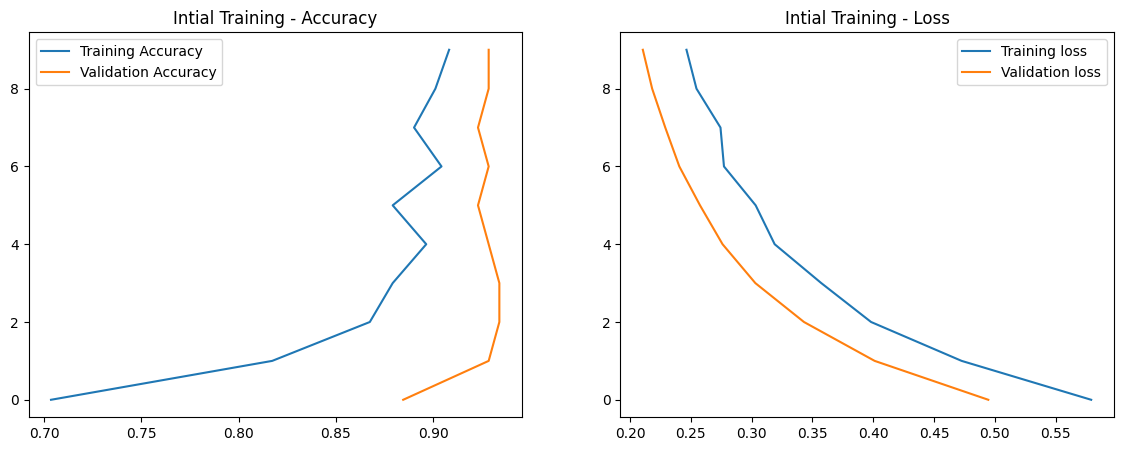

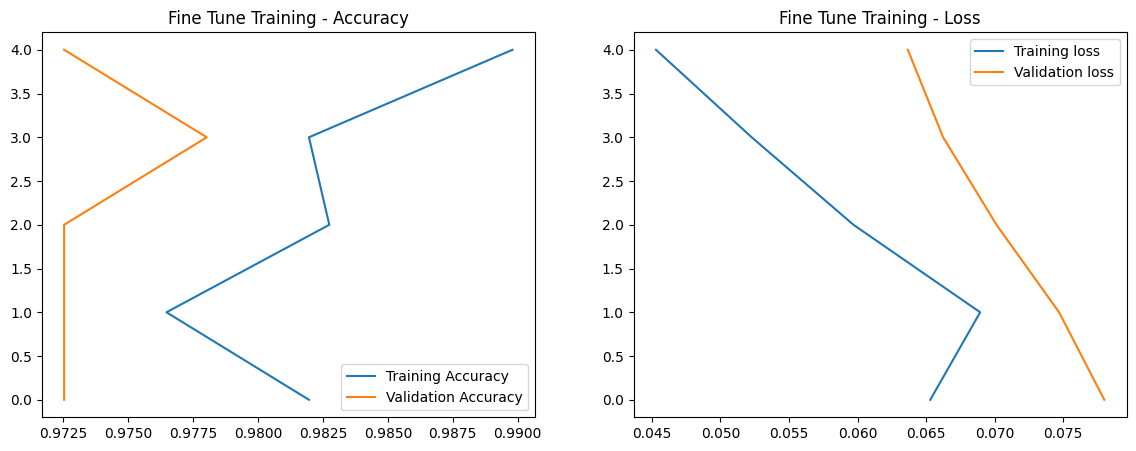

In [22]:
# plot training history

def plot_history(history,title):
  acc=history.history['accuracy']
  val_acc=history.history['val_accuracy']
  loss=history.history['loss']
  val_loss=history.history['val_loss']

  epochs = range(len(acc))

  plt.figure(figsize=(14,5))

  plt.subplot(1,2,1)
  plt.plot(acc,epochs,label='Training Accuracy')
  plt.plot(val_acc,epochs,label='Validation Accuracy')
  plt.title(f"{title} - Accuracy")
  plt.legend()

  plt.subplot(1,2,2)
  plt.plot(loss,epochs,label='Training loss')
  plt.plot(val_loss,epochs,label='Validation loss')
  plt.title(f"{title} - Loss")
  plt.legend()

  plt.show()


plot_history(hist,"Intial Training")
plot_history(fine_tune_history,"Fine Tune Training")

In [23]:
# 💾 10. Save model
model.save('exception_tl_model.h5')

In [24]:
model.save('exception_tl_model.keras')

In [25]:
from tensorflow.keras.models import load_model
model = load_model('exception_tl_model.keras')

In [26]:
from tensorflow.keras.preprocessing.image import load_img,img_to_array
import numpy as np

def predict_img(model,img_path):
  img = load_img(img_path,target_size=(299,299))
  img_array = img_to_array(img)
  img_ary = np.expand_dims(img_array,axis=0)
  img_ary = tf.keras.applications.xception.preprocess_input(img_ary)

  pred = model.predict(img_ary)
  predict_class = np.argmax(pred,axis=1)
  class_indx = {v: k for k,v in train_generator.class_indices.items()}
  return class_indx[predict_class[0]]

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
Predicted Label:  daisy


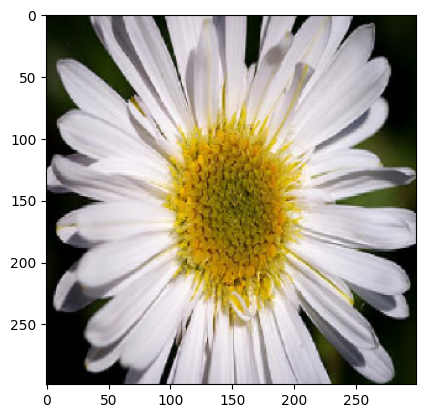

In [27]:
img_pth = "/content/dataset/test/daisy/12193032636_b50ae7db35_n_jpg.rf.e6c4eeb71c56e793a0d85f6d979dbe20.jpg"
pred_label = predict_img(model,img_pth)
print("Predicted Label: ",pred_label)
plt.imshow(load_img(img_pth,target_size=(299,299)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Predicted Label:  dandelion


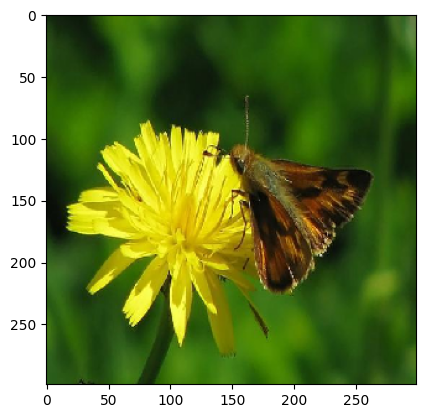

In [28]:
img_pth = "/content/dataset/test/dandelion/1241011700_261ae180ca_jpg.rf.53eafd845f17fbf30ebd87b04312a4e8.jpg"
pred_label = predict_img(model,img_pth)
print("Predicted Label: ",pred_label)
plt.imshow(load_img(img_pth,target_size=(299,299)))